# 🎯 Ziel dieser Lektion: Neuronale Netze Grundlagen

**Was wollen wir erreichen?** 
Wir lernen die Grundbausteine eines neuronalen Netzes kennen und bauen das Modell eines einfachen biologischen Neurons nach.

**Von wo nach wo? (Problem & Ziel)** 
- **Ausgangssituation (Gegeben):** Wir haben einfache Eingabedaten (Zahlen) und wissen noch nicht, wie ein Computer daraus lernen kann.
- **Endziel (Gesucht):** Das Neuron soll die Daten verarbeiten und am Ende eine einfache, klare Entscheidung treffen (z. B. eine 0 oder 1 ausgeben).

### 🛤️ Ablauf (Schritt-für-Schritt)
`Eingabedaten erhalten` ➔ `Mit Gewichten multiplizieren` ➔ `Bias addieren` ➔ `Aktivierungsfunktion anwenden` ➔ `Entscheidung (Output) berechnen`


## Exercise 1

**Cell 1:**
Exploring advanced activation functions such as ReLU and their benefits.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `def sigmoid(x):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `return 1 / (1 + np.exp(-np.clip(x, -500, 500)))` | Berechnet die Exponentialfunktion (e^x). Dies ist ein wichtiger Baustein für viele Aktivierungsfunktionen wie Sigmoid. |
| `s = sigmoid(x)` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `return s * (1 - s)` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `for tiefe in tiefen:` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `gradient_staerken.append(np.mean(np.abs(gradien...` | Berechnet den Durchschnitt (Mittelwert) einer Liste von Zahlen. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print(f"Gradient nach 1 Schicht:  {gradient_sta...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


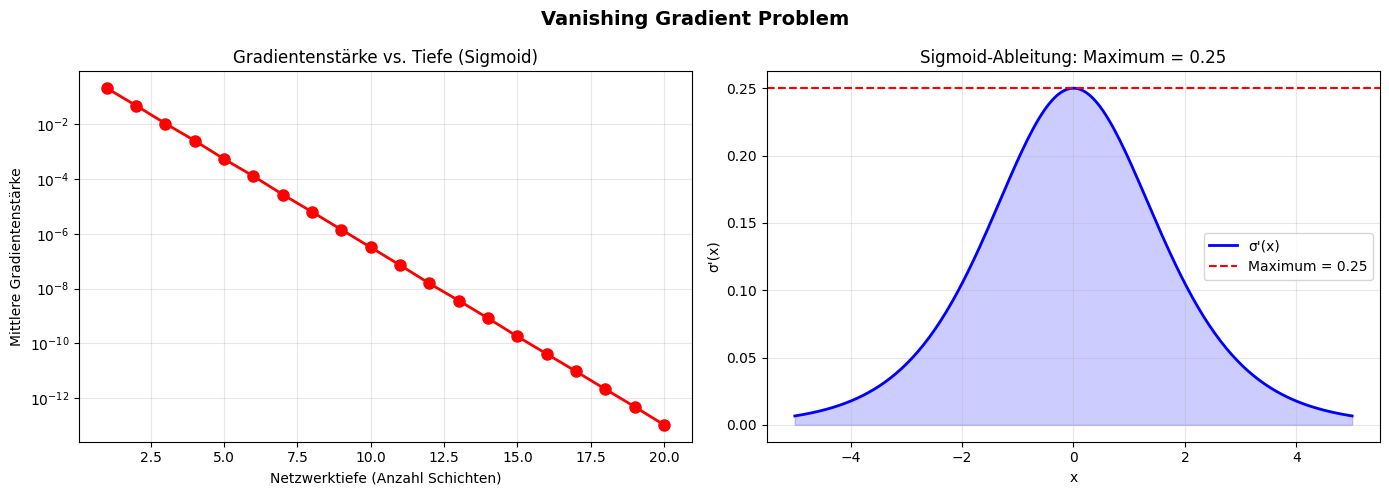

Gradient nach 1 Schicht:  0.212320
Gradient nach 10 Schichten: 0.000000
Gradient nach 20 Schichten: 0.0000000000

Fazit: Gradient schrumpft exponentiell → Vanishing Gradient Problem!


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 1: Grundlagen Neuronaler Netze
# Niveau: Experten
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Demonstrate the vanishing gradient problem through deep sigmoid networks
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_ableitung(x):
    s = sigmoid(x)
    return s * (1 - s)

# Gradienten durch verschiedene Tiefen simulieren
np.random.seed(42)
tiefen = range(1, 21)
gradient_staerken = []

for tiefe in tiefen:
    # Simuliere Gradient durch 'tiefe' Sigmoid-Schichten
    x = np.random.randn(100)
    gradient = np.ones(100)
    for _ in range(tiefe):
        gradient = gradient * sigmoid_ableitung(x)
        x = sigmoid(x)
    gradient_staerken.append(np.mean(np.abs(gradient)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vanishing Gradient Problem', fontsize=14, fontweight='bold')

ax1.plot(list(tiefen), gradient_staerken, 'ro-', linewidth=2, markersize=8)
ax1.set_xlabel('Netzwerktiefe (Anzahl Schichten)')
ax1.set_ylabel('Mittlere Gradientenstärke')
ax1.set_title('Gradientenstärke vs. Tiefe (Sigmoid)')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Max Sigmoid-Ableitung
x_vals = np.linspace(-5, 5, 200)
ax2.plot(x_vals, sigmoid_ableitung(x_vals), 'b-', linewidth=2, label="σ'(x)")
ax2.axhline(y=0.25, color='red', linestyle='--', label='Maximum = 0.25')
ax2.fill_between(x_vals, sigmoid_ableitung(x_vals), alpha=0.2, color='blue')
ax2.set_title("Sigmoid-Ableitung: Maximum = 0.25")
ax2.set_xlabel('x'); ax2.set_ylabel("σ'(x)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vanishing_gradient.png', dpi=100)
plt.show()
print(f"Gradient nach 1 Schicht:  {gradient_staerken[0]:.6f}")
print(f"Gradient nach 10 Schichten: {gradient_staerken[9]:.6f}")
print(f"Gradient nach 20 Schichten: {gradient_staerken[19]:.10f}")
print("\nFazit: Gradient schrumpft exponentiell → Vanishing Gradient Problem!")


## Exercise 2

**Cell 1:**
Demonstrating the difference between underfitting, optimal fit, and overfitting by adjusting the model's capacity.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `def sigmoid(x):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `return 1 / (1 + np.exp(-np.clip(x, -500, 500)))` | Berechnet die Exponentialfunktion (e^x). Dies ist ein wichtiger Baustein für viele Aktivierungsfunktionen wie Sigmoid. |
| `np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `n_eingabe, n_verst, n_ausgabe = 1, versteckte_n...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `X = X.reshape(-1, 1)` | Ändert die Dimensionen oder Form der Daten, ohne die Daten selbst zu verändern (z.B. aus einer Liste eine 2x2 Matrix machen). |
| `for _ in range(epochen):` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `return vorhersage.flatten()` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `mse = np.mean((np.sin(X) - vorhersage)**2)` | Berechnet den Durchschnitt (Mittelwert) einer Liste von Zahlen. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print("Universal Approximation: Mehr Neuronen →...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


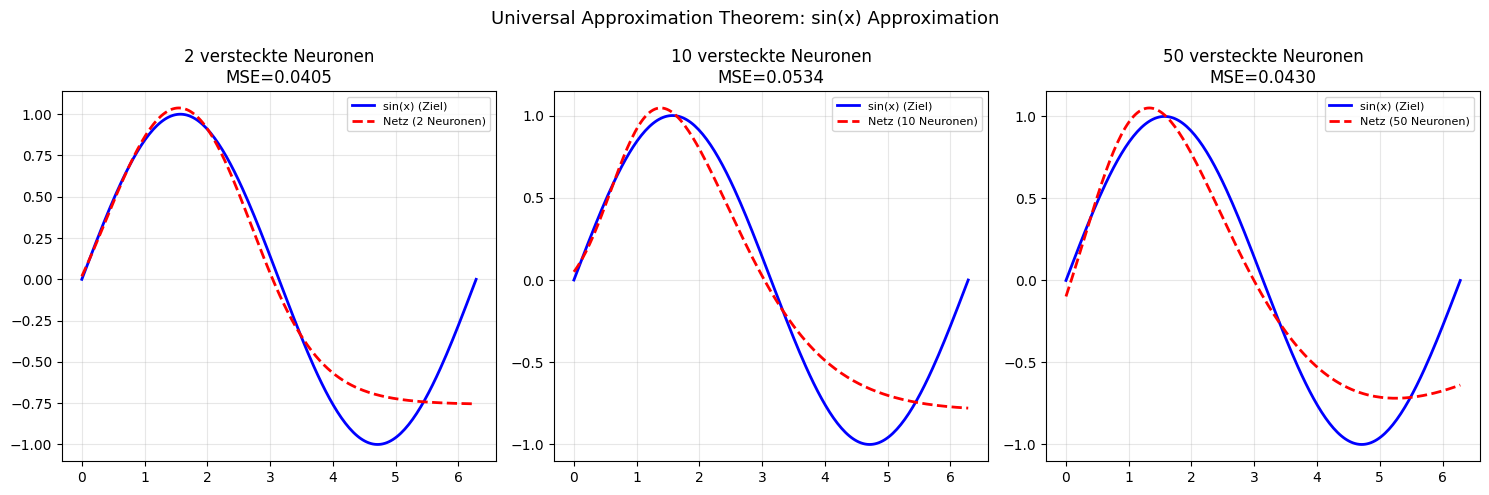

Universal Approximation: Mehr Neuronen → bessere Approximation!


In [2]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 1: Grundlagen Neuronaler Netze
# Niveau: Experten
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Demonstrate the Universal Approximation Theorem empirically
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def approximiere_funktion(X, versteckte_neuronen, ziel_funktion, lernrate=0.1, epochen=5000):
    """Trainiere ein einfaches Netz zur Funktionsapproximation"""
    np.random.seed(42)
    n_eingabe, n_verst, n_ausgabe = 1, versteckte_neuronen, 1
    W1 = np.random.randn(n_eingabe, n_verst) * 0.5
    b1 = np.zeros((1, n_verst))
    W2 = np.random.randn(n_verst, n_ausgabe) * 0.5
    b2 = np.zeros((1, n_ausgabe))
    
    X = X.reshape(-1, 1)
    y = ziel_funktion(X)
    
    for _ in range(epochen):
        # Vorwärts
        z1 = X @ W1 + b1
        a1 = sigmoid(z1)
        a2 = a1 @ W2 + b2
        
        # Rückwärts
        d_out = (a2 - y) / len(X)
        dW2 = a1.T @ d_out
        db2 = d_out.sum(axis=0)
        d_hidden = (d_out @ W2.T) * a1 * (1 - a1)
        dW1 = X.T @ d_hidden
        db1 = d_hidden.sum(axis=0)
        
        W1 -= lernrate * dW1; b1 -= lernrate * db1
        W2 -= lernrate * dW2; b2 -= lernrate * db2
    
    z1 = X @ W1 + b1; a1 = sigmoid(z1); vorhersage = a1 @ W2 + b2
    return vorhersage.flatten()

X = np.linspace(0, 2*np.pi, 200)
ziel = np.sin

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Universal Approximation Theorem: sin(x) Approximation', fontsize=13)

for ax, n_neuronen in zip(axes, [2, 10, 50]):
    vorhersage = approximiere_funktion(X, n_neuronen, ziel)
    ax.plot(X, np.sin(X), 'b-', linewidth=2, label='sin(x) (Ziel)')
    ax.plot(X, vorhersage, 'r--', linewidth=2, label=f'Netz ({n_neuronen} Neuronen)')
    mse = np.mean((np.sin(X) - vorhersage)**2)
    ax.set_title(f'{n_neuronen} versteckte Neuronen\nMSE={mse:.4f}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('universal_approximation.png', dpi=100)
plt.show()
print("Universal Approximation: Mehr Neuronen → bessere Approximation!")


## Exercise 3

**Cell 1:**
A practical demonstration of the Universal Approximation Theorem for modeling any continuous function.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `from sklearn.model_selection import train_test_...` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `tf.random.set_seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X = np.linspace(0, 4*np.pi, 200).reshape(-1, 1)` | Ändert die Dimensionen oder Form der Daten, ohne die Daten selbst zu verändern (z.B. aus einer Liste eine 2x2 Matrix machen). |
| `y = np.sin(X) + np.random.normal(0, 0.3, X.shape)` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `def erstelle_modell(kapazitaet):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `modell = tf.keras.Sequential()` | Erstellt ein leeres, sequenzielles neuronales Netz, bei dem die Schichten einfach eine nach der anderen gestapelt werden. |
| `modell.add(tf.keras.layers.Dense(kapazitaet, ac...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `if kapazitaet > 8:` | Eine Wenn-Dann-Bedingung. Der Code danach wird nur ausgeführt, wenn diese Bedingung wahr ist. |
| `modell.compile(optimizer='adam', loss='mse')` | Wählt Adam als Optimierer aus. Adam ist ein sehr intelligenter Algorithmus, der die Lernrate für jedes Gewicht automatisch anpasst. |
| `return modell` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print("Hohe Kapazität → Overfitting! Niedrige K...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


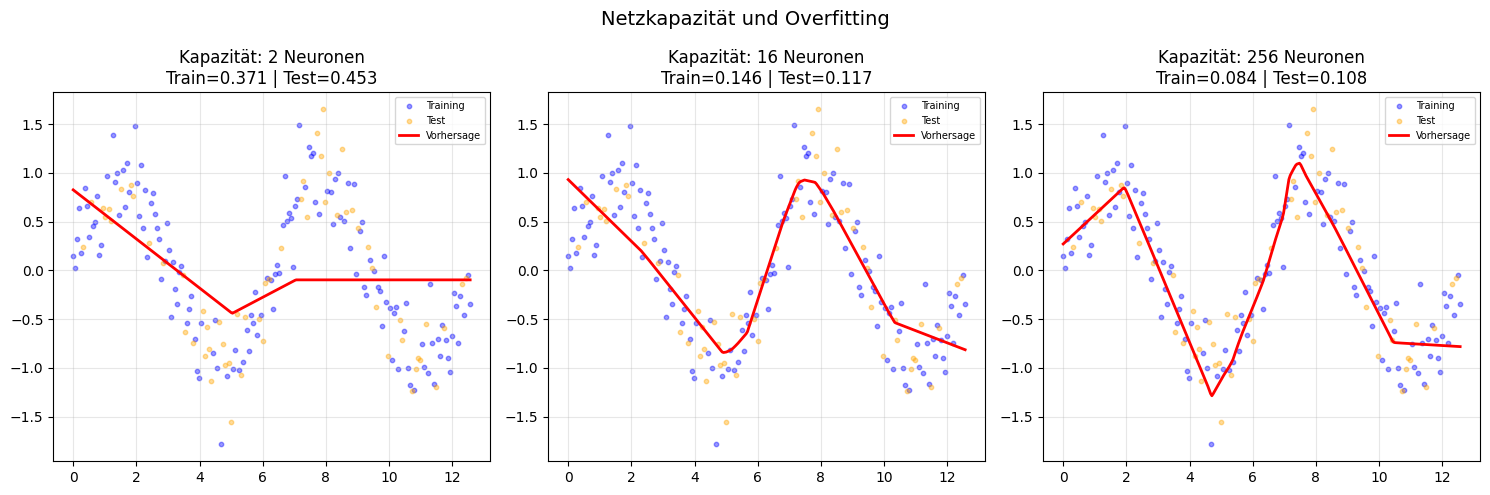

Hohe Kapazität → Overfitting! Niedrige Kapazität → Underfitting!


In [3]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 1: Grundlagen Neuronaler Netze
# Niveau: Experten
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Demonstrate network capacity and overfitting
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

# Synthetische Daten: verrauschte Sinuskurve
X = np.linspace(0, 4*np.pi, 200).reshape(-1, 1)
y = np.sin(X) + np.random.normal(0, 0.3, X.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

def erstelle_modell(kapazitaet):
    """Modell mit unterschiedlicher Kapazität"""
    modell = tf.keras.Sequential()
    modell.add(tf.keras.layers.Dense(kapazitaet, activation='relu', input_shape=(1,)))
    if kapazitaet > 8:
        modell.add(tf.keras.layers.Dense(kapazitaet, activation='relu'))
    modell.add(tf.keras.layers.Dense(1))
    modell.compile(optimizer='adam', loss='mse')
    return modell

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Netzkapazität und Overfitting', fontsize=14)

for ax, kapazitaet in zip(axes, [2, 16, 256]):
    modell = erstelle_modell(kapazitaet)
    history = modell.fit(X_train_s, y_train, validation_data=(X_test_s, y_test),
                         epochs=200, verbose=0)
    
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]
    
    X_plot = np.linspace(0, 4*np.pi, 300).reshape(-1, 1)
    X_plot_s = scaler.transform(X_plot)
    y_pred = modell.predict(X_plot_s, verbose=0)
    
    ax.scatter(X_train, y_train, alpha=0.4, s=10, label='Training', color='blue')
    ax.scatter(X_test, y_test, alpha=0.4, s=10, label='Test', color='orange')
    ax.plot(X_plot, y_pred, 'r-', linewidth=2, label='Vorhersage')
    ax.set_title(f'Kapazität: {kapazitaet} Neuronen\nTrain={train_loss:.3f} | Test={val_loss:.3f}')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kapazitaet_overfitting.png', dpi=100)
plt.show()
print("Hohe Kapazität → Overfitting! Niedrige Kapazität → Underfitting!")
